<a href="https://colab.research.google.com/github/astgregory/Task_15-HandwrittenDigitRecognition/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%8F%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9615.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используя датасет по рукописным буквам английского языка, обучите модель, оцените ее предсказательные способности. Используйте только полносвязанные слои. Поэкспериментируйте с числом слоев и числом нейронов в слое, добейтесь максимальной точности. Используйте куски кода и рекомендации из практической части урока. Нарисуйте графики точности и потерь для обучающей и тестовой выборки, сделайте по ним выводы.

Оценка за задание:
* 1 балл - задача решена с помощью куратора, точность на проверочной выборке ниже 85%
* 2 балла - задача решена с подсказками куратора, точность на проверочной выборке выше 85%
* 3 балла - задача решена самостоятельно, точность на проверочной выборке выше 85%
* 4 балла - задача решена самостоятельно, точность на проверочной выборке выше 93%
* 5 баллов - задача решена самостоятельно, точность на проверочной выборке выше 97%

In [ ]:
import numpy as np
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')

In [ ]:
X = dataset[:,1:785]
Y = dataset[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, shuffle=True)

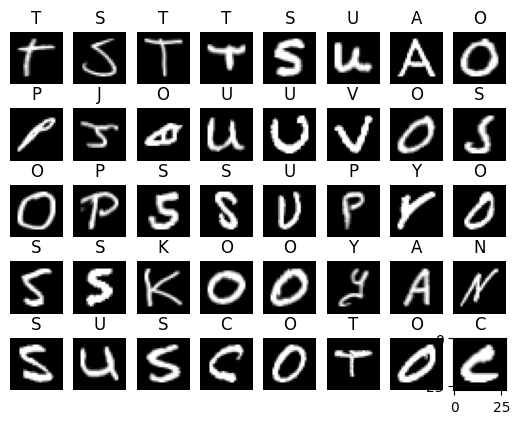

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}

for i in range(40):
    x = x_train[i]
    x = x.reshape((28, 28))
    plt.axis('off')
    im = plt.subplot(5, 8, i+1)
    plt.title(word_dict.get(y_train[i]))
    im.imshow(x, cmap='gray')


In [ ]:
x_train.shape

(297960, 784)

In [ ]:
from tensorflow import keras

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

y_train = keras.utils.to_categorical(y_train, 26)
y_test = keras.utils.to_categorical(y_test, 26)

In [ ]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(456, activation='relu', input_shape=(784,)))
model.add(layers.Dense(26, activation='softmax'))

In [ ]:
model.compile(optimizer='Adam',
   loss='categorical_crossentropy',
   metrics=['accuracy', 'mae'])

In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=1528, epochs=30, verbose=1)

Epoch 1/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6930 - loss: 1.1412 - mae: 0.0352 - val_accuracy: 0.9121 - val_loss: 0.3414 - val_mae: 0.0131
Epoch 2/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9241 - loss: 0.2933 - mae: 0.0114 - val_accuracy: 0.9442 - val_loss: 0.2146 - val_mae: 0.0085
Epoch 3/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9508 - loss: 0.1922 - mae: 0.0077 - val_accuracy: 0.9568 - val_loss: 0.1635 - val_mae: 0.0064
Epoch 4/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9623 - loss: 0.1447 - mae: 0.0059 - val_accuracy: 0.9648 - val_loss: 0.1346 - val_mae: 0.0052
Epoch 5/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9688 - loss: 0.1180 - mae: 0.0048 - val_accuracy: 0.9694 - val_loss: 0.1164 - val_mae: 0.0045
Epoch 6/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9749 - loss: 0.0980 - mae: 0.0041 - val_accuracy: 0.9717 - val_loss: 0.1060 - val_mae: 0.0041
Epoch 7/30
195/195 ━━━━━━━━━

In [ ]:
test_loss, test_accuracy, test_mae = model.evaluate(x_test, y_test)
print('Точность на тестовом образце: {:.2f}%'.format(test_accuracy * 100))
print('Потери на тестовом образце:', test_loss)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9921 - loss: 0.0374 - mae: 0.0011
Точность на тестовом образце: 99.24%
Потери на тестовом образце: 0.03591557592153549


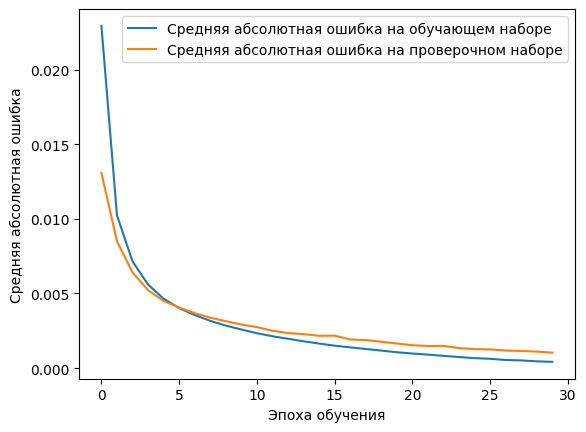

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(history.history['mae'], label='Средняя абсолютная ошибка на обучающем наборе')
plt.plot(history.history['val_mae'], label='Средняя абсолютная ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Средняя абсолютная ошибка')
plt.legend()
plt.show()

График средней абсолютной ошибки говорит нам о том, что модель обучается корректно, показывает хорошие показатели как на обучающем, так и на проверочном наборах. Это свидетельствует о ее способности обобщать информацию и успешно классифицировать рукописные буквы. Также модель не демонстрирует явные признаки переобучения.

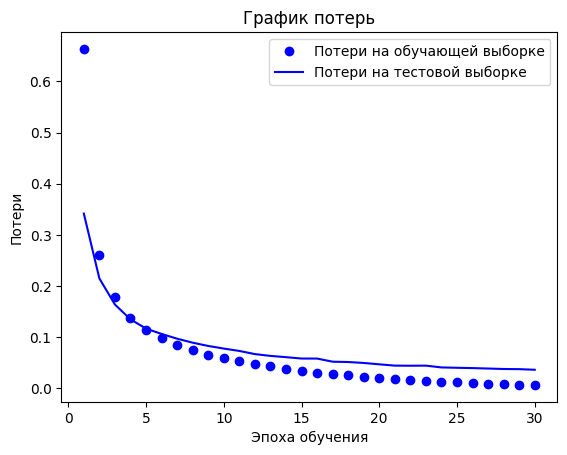

In [ ]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'bo', label='Потери на обучающей выборке')
plt.plot(epochs, val_loss_values, 'b', label='Потери на тестовой выборке')
plt.title('График потерь')
plt.xlabel('Эпоха обучения')
plt.ylabel('Потери')
plt.legend()
plt.show()

График потерь свидетельствует о том, что модель обучается эффективно. Постепенное снижение потерь как на обучающей, так и на тестовой выборках подтверждает, что модель не переобучается, а предсказания становятся более точными.

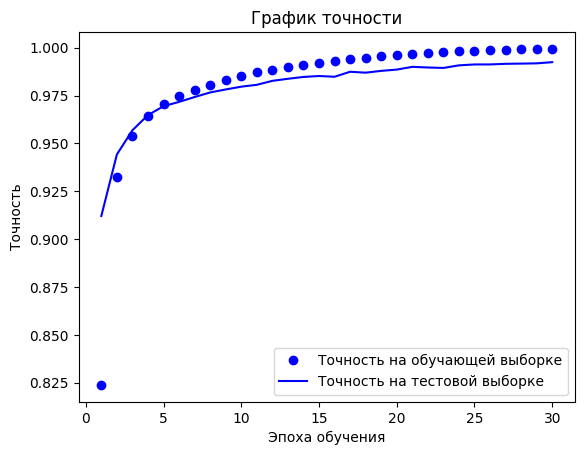

In [ ]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)
plt.plot(epochs, acc_values, 'bo', label='Точность на обучающей выборке')
plt.plot(epochs, val_acc_values, 'b', label='Точность на тестовой выборке')
plt.title('График точности')
plt.xlabel('Эпоха обучения')
plt.ylabel('Точность')
plt.legend()
plt.show()

График точности демонстрирует, что модель достигает высоких результатов как на обучающей, так и на тестовой выборках, с плавным ростом точности на протяжении всего обучения. Это подтверждает, что модель работает хорошо и эффективно справляется с задачей классификации рукописных букв, без признаков переобучения.